# TEA-seq Model Comparison (CellTypist labels)

This notebook:
1. Loads the TEA-seq dataset annotated with CellTypist.
2. Loads all trained topic models under `/data/omics_topic_models/teaseq`.
3. Selects the best model by NMI/ARI against CellTypist labels.
4. Loads MultiVI and MOFA+ baselines.
5. Evaluates kNN (k=5) cell-type prediction for each embedding.


In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

DATA_PATH = "/data/GSE158013/GSM5123951_celltypist.h5mu"
MODELS_DIR = Path("/data/omics_topic_models/teaseq")
BASELINES_DIR = Path("/data/omics_topic_models/teaseq/baselines")
MULTIVI_LATENT_PATH = BASELINES_DIR / "latent_multivi.npy"
MULTIVI_LINEAR_LATENT_PATH = BASELINES_DIR / "latent_multivi_linear.npy"
LDA_LATENT_PATHS = {
    "AmortizedLDA (RNA)": BASELINES_DIR / "latent_amortized_lda_rna.npy",
    "AmortizedLDA (ATAC)": BASELINES_DIR / "latent_amortized_lda_atac.npy",
    "AmortizedLDA (Protein)": BASELINES_DIR / "latent_amortized_lda_prot.npy",
}
MOFA_PATH = BASELINES_DIR / "mdata_mofa.h5mu"


/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load TEA-seq data (annotated with CellTypist)


In [2]:
from omics_topic import MultimodalAmortizedLDA


def ensure_counts_layer(adata):
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()


def binarize_atac(adata_atac):
    X = adata_atac.layers["counts"]
    if sp.issparse(X):
        X = X.tocsr(copy=True)
        X.data = np.ones_like(X.data)
        X.eliminate_zeros()
    else:
        X = (X > 0).astype(np.int8)
    adata_atac.layers["counts"] = X


def load_data():
    mdata = mu.read_h5mu(DATA_PATH)

    ensure_counts_layer(mdata.mod["rna"])
    ensure_counts_layer(mdata.mod["atac"])
    ensure_counts_layer(mdata.mod["prot"])

    # Binarize ATAC counts
    binarize_atac(mdata.mod["atac"])

    # Filter to highly variable genes/peaks (same as training)
    sc.pp.highly_variable_genes(
        mdata.mod["rna"], n_top_genes=2000, flavor="seurat_v3", layer="counts"
    )
    mdata.mod["rna"] = mdata.mod["rna"][:, mdata.mod["rna"].var["highly_variable"]].copy()

    sc.pp.highly_variable_genes(
        mdata.mod["atac"], n_top_genes=10000, flavor="seurat_v3", layer="counts"
    )
    mdata.mod["atac"] = mdata.mod["atac"][:, mdata.mod["atac"].var["highly_variable"]].copy()

    mdata.update()

    print(f"RNA: {mdata.mod['rna'].shape}")
    print(f"ATAC: {mdata.mod['atac'].shape}")
    print(f"Protein: {mdata.mod['prot'].shape}")

    return mdata


def find_true_umap(mdata):
    if "X_umap" in mdata.obsm:
        return mdata.obsm["X_umap"], "mdata"
    for mod_name in ("rna", "atac", "prot"):
        if mod_name in mdata.mod and "X_umap" in mdata.mod[mod_name].obsm:
            return mdata.mod[mod_name].obsm["X_umap"], mod_name
    return None, None


mdata = load_data()

true_umap, true_umap_source = find_true_umap(mdata)
if true_umap is not None:
    print(f"Found true UMAP coordinates in {true_umap_source}")
else:
    print("No precomputed UMAP coordinates found; using representation-derived UMAP.")


if "celltypist_label" not in mdata.mod["rna"].obs.columns:
    raise ValueError("CellTypist labels not found in RNA obs. Run annotation first.")

cell_types = mdata.mod["rna"].obs["celltypist_label"].astype(str).values
print(f"Cell types: {len(np.unique(cell_types))} unique labels")
print(pd.Series(cell_types).value_counts())


RNA: (5805, 2000)
ATAC: (5805, 10000)
Protein: (5805, 46)
Cell types: 10 unique labels
Tcm/Naive helper T cells       3059
Naive B cells                  1050
Tem/Trm cytotoxic T cells       617
CD16+ NK cells                  387
Classical monocytes             263
MAIT cells                      166
Memory B cells                  148
Tem/Effector helper T cells      77
Non-classical monocytes          26
HSC/MPP                          12
Name: count, dtype: int64


## 2. Load all trained topic models and compute metrics


In [3]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


def parse_model_config(dirname):
    config = {}
    if "horseshoe" in dirname:
        config["feature_prior_type"] = "horseshoe"
    else:
        config["feature_prior_type"] = "logistic_normal"

    if "weight_cell" in dirname:
        config["weight_mode"] = "cell"
    elif "weight_universal" in dirname:
        config["weight_mode"] = "universal"
    else:
        config["weight_mode"] = "equal"

    if "learnable_disp_global" in dirname:
        config["dispersion"] = "learnable_global"
    elif "learnable_disp_pergene" in dirname:
        config["dispersion"] = "learnable_pergene"
    else:
        config["dispersion"] = "fixed"

    return config


def compute_cell_type_correlation(theta, labels):
    topic_assignments = np.argmax(theta, axis=1)
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    ari = adjusted_rand_score(labels_encoded, topic_assignments)
    nmi = normalized_mutual_info_score(labels_encoded, topic_assignments)
    return {"ARI": ari, "NMI": nmi}


model_dirs = sorted(
    [d for d in MODELS_DIR.iterdir() if d.is_dir() and d.name.startswith("prior_")]
)
print(f"Found {len(model_dirs)} candidate model dirs")

# Prepare data for loading
mdata_setup, modality_names, feat_counts = MultimodalAmortizedLDA.setup_mudata(
    mdata,
    modality_order=["rna", "atac", "prot"],
    layers="counts",
)
adata_flat = mdata.uns["_flattened_ann_data"]

results = []
for model_dir in model_dirs:
    model_path = model_dir / "model"
    if not model_path.exists():
        continue

    print(f"Loading {model_dir.name}...")
    try:
        model = MultimodalAmortizedLDA.load(str(model_path), adata=adata_flat)
        theta = model.get_latent_representation(batch_size=mdata.n_obs)
        theta_array = np.asarray(theta)

        config = parse_model_config(model_dir.name)
        diversity = model.get_topic_diversity()
        diversity_rna = model.get_topic_diversity(modality="rna")
        diversity_atac = model.get_topic_diversity(modality="atac")
        diversity_prot = model.get_topic_diversity(modality="prot")

        corr_metrics = compute_cell_type_correlation(theta_array, cell_types)

        result = {
            "model_name": model_dir.name,
            **config,
            "diversity": diversity,
            "diversity_rna": diversity_rna,
            "diversity_atac": diversity_atac,
            "diversity_prot": diversity_prot,
            "ARI": corr_metrics["ARI"],
            "NMI": corr_metrics["NMI"],
            "theta": theta_array,
        }
        results.append(result)

        print(
            f"  Diversity: {diversity:.4f}, "
            f"ARI: {corr_metrics['ARI']:.4f}, "
            f"NMI: {corr_metrics['NMI']:.4f}"
        )
    except Exception as e:
        print(f"  Error loading model: {e}")

print(f"Successfully loaded {len(results)} models")


Found 18 candidate model dirs
Loading prior_horseshoe_weight_cell...
INFO     File /data/omics_topic_models/teaseq/prior_horseshoe_weight_cell/model/model.pt already downloaded        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<06:33,  2.54it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<06:40,  2.49it/s, v_num=1]
  Diversity: 0.0440, ARI: 0.3654, NMI: 0.3451
Loading prior_horseshoe_weight_cell_learnable_disp_global...
INFO     File /data/omics_topic_models/teaseq/prior_horseshoe_weight_cell_learnable_disp_global/model/model.pt     
         already downloaded                                                                                        


...

Epoch 1/1000:   0%|          | 1/1000 [00:00<02:43,  6.10it/s, v_num=1]
  Diversity: 0.0067, ARI: 0.3452, NMI: 0.5261
Loading prior_logistic_normal_weight_universal_learnable_disp_pergene...
INFO     File                                                                                                      
         /data/omics_topic_models/teaseq/prior_logistic_normal_weight_universal_learnable_disp_pergene/model/model.
         pt already downloaded                                                                                     


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:38,  6.29it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|          | 1/1000 [00:00<02:45,  6.02it/s, v_num=1]
  Diversity: 0.0058, ARI: 0.5575, NMI: 0.5656
Successfully loaded 18 models


## 3. Select best model by NMI


In [4]:
results_display = [{k: v for k, v in r.items() if k != "theta"} for r in results]

df_results = pd.DataFrame(results_display)
if df_results.empty:
    raise ValueError("No models loaded. Check MODELS_DIR and model paths.")

# Sort by NMI
_df_sorted = df_results.sort_values("NMI", ascending=False)
print("Model Comparison (sorted by NMI):")
print(_df_sorted.to_string(index=False))

best_idx = _df_sorted["NMI"].idxmax()
best_model_name = _df_sorted.loc[best_idx, "model_name"]
best_result = next(r for r in results if r["model_name"] == best_model_name)

print(f"Best model: {best_model_name}")
print(f"  Feature prior: {best_result['feature_prior_type']}")
print(f"  Weight mode: {best_result['weight_mode']}")
print(f"  Dispersion: {best_result['dispersion']}")
print(f"  NMI: {best_result['NMI']:.4f}")
print(f"  ARI: {best_result['ARI']:.4f}")
print(f"  Diversity: {best_result['diversity']:.4f}")

theta_best = best_result["theta"]


Model Comparison (sorted by NMI):
                                                   model_name feature_prior_type weight_mode        dispersion  diversity  diversity_rna  diversity_atac  diversity_prot      ARI      NMI
                       prior_logistic_normal_weight_universal    logistic_normal   universal             fixed   0.019984       0.020201        0.010988        0.028763 0.595191 0.580722
prior_logistic_normal_weight_universal_learnable_disp_pergene    logistic_normal   universal learnable_pergene   0.005836       0.005113        0.008755        0.003639 0.557508 0.565562
                            prior_logistic_normal_weight_cell    logistic_normal        cell             fixed   0.019597       0.019458        0.010819        0.028513 0.490846 0.557601
                           prior_logistic_normal_weight_equal    logistic_normal       equal             fixed   0.009789       0.008396        0.009248        0.011723 0.441215 0.536433
     prior_logistic_normal_weig

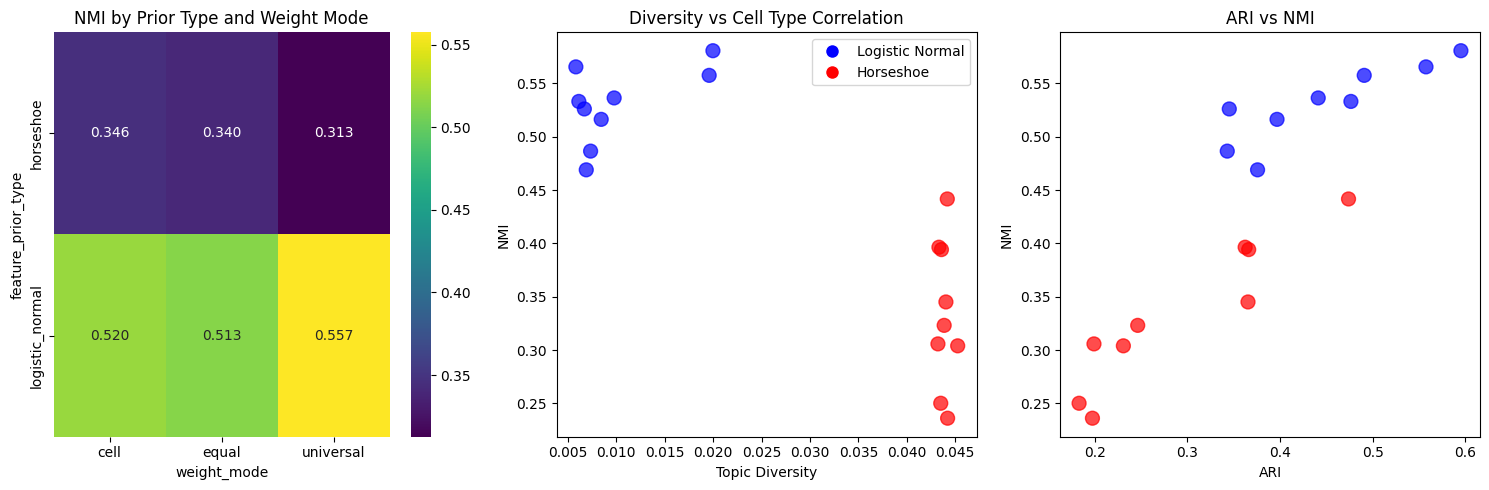

In [5]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
df_pivot = _df_sorted.pivot_table(
    values="NMI", index="feature_prior_type", columns="weight_mode", aggfunc="mean"
)
sns.heatmap(df_pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("NMI by Prior Type and Weight Mode")

ax = axes[1]
colors = _df_sorted["feature_prior_type"].map({"logistic_normal": "blue", "horseshoe": "red"})
ax.scatter(_df_sorted["diversity"], _df_sorted["NMI"], c=colors, s=100, alpha=0.7)
ax.set_xlabel("Topic Diversity")
ax.set_ylabel("NMI")
ax.set_title("Diversity vs Cell Type Correlation")
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markersize=10, label="Logistic Normal"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markersize=10, label="Horseshoe"),
    ]
)

ax = axes[2]
ax.scatter(_df_sorted["ARI"], _df_sorted["NMI"], c=colors, s=100, alpha=0.7)
ax.set_xlabel("ARI")
ax.set_ylabel("NMI")
ax.set_title("ARI vs NMI")

plt.tight_layout()
plt.show()


## 4. Load MultiVI, Linear MultiVI, AmortizedLDA, and MOFA+ baselines


In [6]:
latent_multivi = None
if MULTIVI_LATENT_PATH.exists():
    latent_multivi = np.load(MULTIVI_LATENT_PATH)
    print(f"Loaded MultiVI latent: {latent_multivi.shape}")
else:
    print(f"MultiVI latent file not found: {MULTIVI_LATENT_PATH}")

latent_multivi_linear = None
if MULTIVI_LINEAR_LATENT_PATH.exists():
    latent_multivi_linear = np.load(MULTIVI_LINEAR_LATENT_PATH)
    print(f"Loaded MultiVI Linear latent: {latent_multivi_linear.shape}")
else:
    print(f"MultiVI Linear latent file not found: {MULTIVI_LINEAR_LATENT_PATH}")

latent_lda = {}
for name, path in LDA_LATENT_PATHS.items():
    if path.exists():
        latent_lda[name] = np.load(path)
        print(f"Loaded {name} latent: {latent_lda[name].shape}")
    else:
        print(f"{name} latent not found: {path}")

latent_mofa = None
if MOFA_PATH.exists():
    mdata_mofa = mu.read_h5mu(MOFA_PATH)
    latent_mofa = np.asarray(mdata_mofa.obsm["X_mofa"])
    print(f"Loaded MOFA+ latent: {latent_mofa.shape}")
else:
    print(f"MOFA+ MuData not found: {MOFA_PATH}")


MultiVI latent file not found: /data/omics_topic_models/teaseq/baselines/latent_multivi.npy
Loaded MOFA+ latent: (5805, 10)


## 5. kNN classification comparison


In [10]:
def evaluate_knn_classification(X, y, k=5, test_size=0.2, random_state=42):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)
    return {
        "accuracy": accuracy_score(y_val, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
    }

cell_types_array = cell_types
knn_results = {}

print("Evaluating Best Topic Model...")
knn_results["Topic Model (Best)"] = evaluate_knn_classification(theta_best-1, cell_types_array, k=5)
print(f"  Accuracy: {knn_results['Topic Model (Best)']['accuracy']:.4f}")
print(f"  Balanced Accuracy: {knn_results['Topic Model (Best)']['balanced_accuracy']:.4f}")

if latent_multivi is not None:
    print("Evaluating MultiVI...")
    knn_results["MultiVI"] = evaluate_knn_classification(latent_multivi, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MultiVI']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MultiVI']['balanced_accuracy']:.4f}")

if latent_multivi_linear is not None:
    print("Evaluating MultiVI Linear...")
    knn_results["MultiVI Linear"] = evaluate_knn_classification(latent_multivi_linear, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MultiVI Linear']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MultiVI Linear']['balanced_accuracy']:.4f}")

if latent_mofa is not None:
    print("Evaluating MOFA+...")
    knn_results["MOFA+"] = evaluate_knn_classification(latent_mofa, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results['MOFA+']['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results['MOFA+']['balanced_accuracy']:.4f}")

for name, latent in latent_lda.items():
    print(f"Evaluating {name}...")
    knn_results[name] = evaluate_knn_classification(latent, cell_types_array, k=5)
    print(f"  Accuracy: {knn_results[name]['accuracy']:.4f}")
    print(f"  Balanced Accuracy: {knn_results[name]['balanced_accuracy']:.4f}")


Evaluating Best Topic Model...
  Accuracy: 0.8725
  Balanced Accuracy: 0.5809
Evaluating MOFA+...
  Accuracy: 0.9139
  Balanced Accuracy: 0.7781


In [11]:
print("Evaluating other top topic models...")

top_models = _df_sorted.head(3)["model_name"].tolist()
for model_name in top_models:
    result = next(r for r in results if r["model_name"] == model_name)
    theta = result["theta"]
    short_name = f"Topic: {result['feature_prior_type'][:4]}_{result['weight_mode'][:4]}_{result['dispersion'][:4]}"
    knn_results[short_name] = evaluate_knn_classification(theta, cell_types_array, k=5)
    print(
        f"{short_name}: Acc={knn_results[short_name]['accuracy']:.4f}, "
        f"Balanced={knn_results[short_name]['balanced_accuracy']:.4f}"
    )


Evaluating other top topic models...
Topic: logi_univ_fixe: Acc=0.8734, Balanced=0.5927
Topic: logi_univ_lear: Acc=0.8381, Balanced=0.5515
Topic: logi_cell_fixe: Acc=0.8794, Balanced=0.6405


FINAL COMPARISON: kNN (k=5) Classification Results
                Model  Accuracy  Balanced Accuracy
                MOFA+  0.913867           0.778105
Topic: logi_cell_fixe  0.879414           0.640495
Topic: logi_univ_fixe  0.873385           0.592665
   Topic Model (Best)  0.872524           0.580885
Topic: logi_univ_lear  0.838071           0.551501


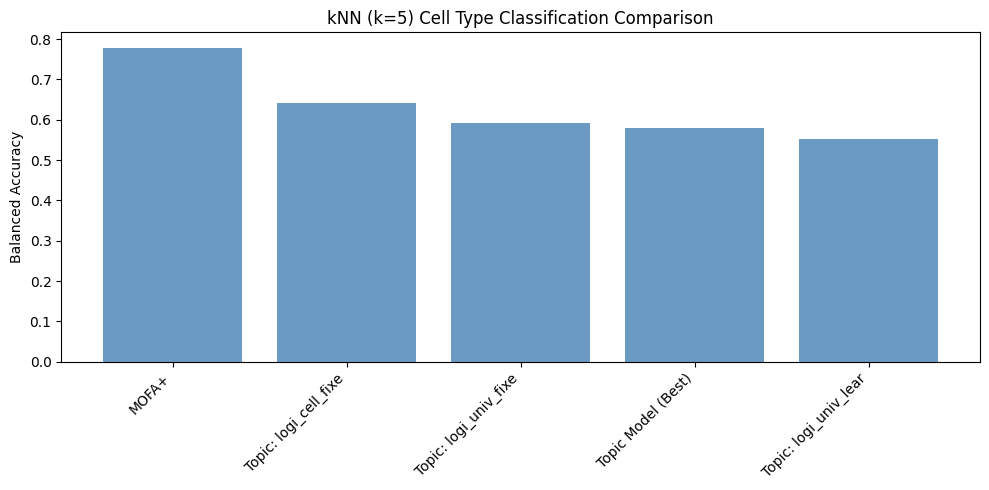

In [12]:
summary_df = pd.DataFrame(
    {
        "Model": list(knn_results.keys()),
        "Accuracy": [r["accuracy"] for r in knn_results.values()],
        "Balanced Accuracy": [r["balanced_accuracy"] for r in knn_results.values()],
    }
).sort_values("Balanced Accuracy", ascending=False)

print("FINAL COMPARISON: kNN (k=5) Classification Results")
print(summary_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(summary_df["Model"], summary_df["Balanced Accuracy"], color="steelblue", alpha=0.85)
ax.set_ylabel("Balanced Accuracy")
ax.set_title("kNN (k=5) Cell Type Classification Comparison")
ax.set_xticklabels(summary_df["Model"], rotation=45, ha="right")
for i, value in enumerate(summary_df["Balanced Accuracy"]):
    ax.text(i, value + 0.002, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()

BASELINES_DIR.mkdir(parents=True, exist_ok=True)
summary_path = BASELINES_DIR / "knn_summary.csv"
summary_df.to_csv(summary_path, index=False)
topic_metrics_path = BASELINES_DIR / "topic_model_metrics.csv"
_df_sorted.to_csv(topic_metrics_path, index=False)
plot_path = BASELINES_DIR / "knn_comparison.png"
fig.savefig(plot_path, dpi=200)
plt.show()
print(f"Saved kNN summary to: {summary_path}")
print(f"Saved topic model metrics to: {topic_metrics_path}")
print(f"Saved comparison plot to: {plot_path}")


## 6. UMAPs by representation (Leiden + Cell Type)


In [ ]:
import anndata as ad

def plot_umap_for_rep(X, labels, title_prefix, n_neighbors=15, min_dist=0.3, true_umap=None):
    adata = ad.AnnData(np.asarray(X))
    adata.obs["cell_type"] = pd.Categorical(labels)

    sc.pp.neighbors(adata, use_rep="X", n_neighbors=n_neighbors, metric="cosine")
    sc.tl.umap(adata, min_dist=min_dist)
    sc.tl.leiden(adata, key_added="leiden")

    rep_umap = adata.obsm.get("X_umap").copy()
    use_true = (
        true_umap is not None
        and np.asarray(true_umap).shape[0] == adata.n_obs
        and np.asarray(true_umap).shape[1] == rep_umap.shape[1]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    if use_true:
        adata.obsm["X_umap"] = np.asarray(true_umap)
        sc.pl.umap(
            adata,
            color="leiden",
            ax=axes[0],
            show=False,
            title=f"{title_prefix}: Leiden (true UMAP)",
        )
        adata.obsm["X_umap"] = rep_umap
    else:
        sc.pl.umap(
            adata,
            color="leiden",
            ax=axes[0],
            show=False,
            title=f"{title_prefix}: Leiden",
        )

    sc.pl.umap(
        adata,
        color="cell_type",
        ax=axes[1],
        show=False,
        title=f"{title_prefix}: Cell Type",
    )
    plt.tight_layout()
    plt.show()


print("\nUMAPs for topic model (best)...")
plot_umap_for_rep(theta_best, cell_types_array, "Topic Model (Best)", true_umap=true_umap)

if latent_multivi is not None:
    print("\nUMAPs for MultiVI...")
    plot_umap_for_rep(latent_multivi, cell_types_array, "MultiVI", true_umap=true_umap)

if latent_multivi_linear is not None:
    print("\nUMAPs for MultiVI Linear...")
    plot_umap_for_rep(latent_multivi_linear, cell_types_array, "MultiVI Linear", true_umap=true_umap)

if latent_mofa is not None:
    print("\nUMAPs for MOFA+...")
    plot_umap_for_rep(latent_mofa, cell_types_array, "MOFA+", true_umap=true_umap)

for name, latent in latent_lda.items():
    print(f"\nUMAPs for {name}...")
    plot_umap_for_rep(latent, cell_types_array, name, true_umap=true_umap)


## Notes

- This notebook expects the CellTypist-annotated TEA-seq file:
  `/data/GSE158013/GSM5123951_celltypist.h5mu`
- Topic models are expected under `/data/omics_topic_models/teaseq` with `prior_*` directories.
- Baseline outputs are expected under `/data/omics_topic_models/teaseq/baselines`.
